In [1]:
!pip install keras_unet_collection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.9 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
import tensorflow as tf
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
import keras
import time
from tqdm import tqdm
from keras.optimizers import Adam
from keras_unet_collection import models
from keras.callbacks import EarlyStopping

In [3]:
img_size = 128

In [4]:
cxrs = np.load('/kaggle/input/lung-segmentation-dataset-ch0/train/cxrs')
masks = np.load('/kaggle/input/lung-segmentation-dataset-ch0/train/masks')

print(np.shape(cxrs))
print(np.shape(masks))

(55085, 128, 128)
(55085, 128, 128)


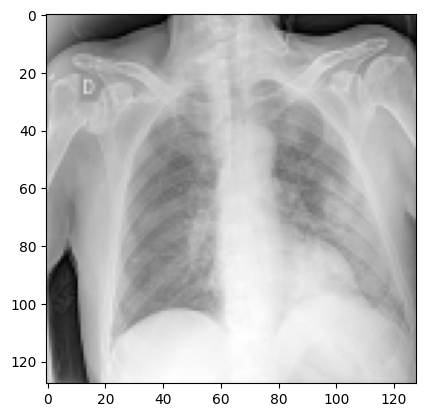

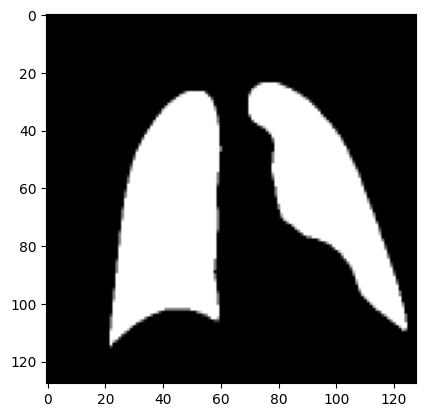

In [5]:
idx = 9
plt.imshow(cxrs[idx], cmap='gray')
plt.show()
plt.imshow(masks[idx], cmap='gray')
plt.show()

In [6]:
random.seed(42)

idx_list = []
for i in range(np.shape(cxrs)[0]):
    idx_list.append(i)
random.shuffle(idx_list)

cxrs_shuffled = np.zeros(np.shape(cxrs))
masks_shuffled = np.zeros(np.shape(masks))
for i in tqdm(range(len(idx_list))):
    idx = idx_list[i]
    cxrs_shuffled[i] = cxrs[idx]
    masks_shuffled[i] = masks[idx]

del cxrs
del masks

print(np.shape(cxrs_shuffled))
print(np.shape(masks_shuffled))

100%|██████████| 55085/55085 [00:12<00:00, 4581.01it/s]

(55085, 128, 128)
(55085, 128, 128)


In [7]:
x_data = cxrs_shuffled.reshape(-1, img_size, img_size, 1)
del cxrs_shuffled
x_data = np.array(x_data) / 255

y_data = masks_shuffled.reshape(-1, img_size, img_size, 1)
del masks_shuffled
y_data = np.array(y_data) / 255

print(np.shape(x_data))
print(np.shape(y_data))

(55085, 128, 128, 1)
(55085, 128, 128, 1)


In [8]:
val_ratio = 0.1
train_size = int(np.shape(x_data)[0] * (1 - val_ratio))

x_train = x_data[:train_size]
x_val = x_data[train_size:]
del x_data

y_train = y_data[:train_size]
y_val = y_data[train_size:]
del y_data

print(np.shape(x_train))
print(np.shape(y_train))
print(np.shape(x_val))
print(np.shape(y_val))

(49576, 128, 128, 1)
(49576, 128, 128, 1)
(5509, 128, 128, 1)
(5509, 128, 128, 1)


In [9]:
threshold = 0.5

def dice_coef(y_true, y_pred, smooth=1):
    y_pred_bin = K.cast((y_pred >= threshold), tf.float32)
    intersection = K.sum(K.abs(y_true * y_pred_bin), axis=[1])
    combination = K.sum(y_true, [1]) + K.sum(y_pred_bin, [1])
    dice = K.mean((intersection + intersection + smooth) / (combination + smooth), axis=0)
    return dice

def iou_coef(y_true, y_pred, smooth=1):
    y_pred_bin = K.cast((y_pred >= threshold), tf.float32)
    intersection = K.sum(K.abs(y_true * y_pred_bin), axis=[1])
    union = K.sum(y_true, [1]) + K.sum(y_pred_bin, [1]) - intersection
    iou = K.mean((intersection + smooth) / (union + smooth), axis=0)
    return iou

In [ ]:
attunet = models.att_unet_2d(
    input_size=(img_size, img_size, 1),
    filter_num=[16, 32, 64, 128, 256],
    n_labels=1,
    stack_num_down=2, 
    stack_num_up=2,
    activation='ReLU', 
    atten_activation='ReLU', 
    attention='add', 
    output_activation='Sigmoid',
    pool='max'
)

attunet.compile(optimizer=Adam(learning_rate=2e-4), loss='binary_crossentropy', metrics=[dice_coef, iou_coef])

attunet.summary()

Model: "attunet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down0_0 (Conv2D)  │ (None, 128, 128, 16)   │            160 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down0_0_activati… │ (None, 128, 128, 16)   │              0 │ attunet_down0_0[0][0]  │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down0_1 (Conv2D)  │ (None, 128, 128, 16)   │          2,320 │ attunet_down0_0_activ… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down0_1_activati… │ (None, 128, 128, 16)   │              0 │ attunet_down0_1[0][0]  │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down1_encode_max… │ (None, 64, 64, 16)     │              0 │ attunet_down0_1_activ… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down1_conv_0      │ (None, 64, 64, 32)     │          4,640 │ attunet_down1_encode_… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down1_conv_0_act… │ (None, 64, 64, 32)     │              0 │ attunet_down1_conv_0[… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down1_conv_1      │ (None, 64, 64, 32)     │          9,248 │ attunet_down1_conv_0_… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down1_conv_1_act… │ (None, 64, 64, 32)     │              0 │ attunet_down1_conv_1[… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down2_encode_max… │ (None, 32, 32, 32)     │              0 │ attunet_down1_conv_1_… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down2_conv_0      │ (None, 32, 32, 64)     │         18,496 │ attunet_down2_encode_… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down2_conv_0_act… │ (None, 32, 32, 64)     │              0 │ attunet_down2_conv_0[… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down2_conv_1      │ (None, 32, 32, 64)     │         36,928 │ attunet_down2_conv_0_… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 1,995,341 (7.61 MB)

 Trainable params: 1,995,341 (7.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
### history = model.fit(x, y, batch_size, epochs)

history_train_dice = []
history_train_iou = []
history_train_loss = []
history_val_dice = []
history_val_iou = []
history_val_loss = []

def custom_fit(model, x_train, y_train, x_val, y_val, epochs, batch_size):
    best_model = model
    best_val_loss = 0.0
    num_train_samples = np.shape(x_train)[0]
    num_val_samples = np.shape(x_val)[0]

    for epoch in range(epochs):
        print('Epoch {}/{}'.format(epoch + 1, epochs))

        train_dice, train_iou, train_loss = 0.0, 0.0, 0.0
        start_time = time.time()
        for i in tqdm(range(0, num_train_samples, batch_size)):
            x_batch = x_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]

            metrics = model.fit(x=x_batch, y=y_batch, batch_size=batch_size, epochs=1, verbose=False).history
            dice = metrics.get('dice_coef')[0]
            iou = metrics.get('iou_coef')[0]
            loss = metrics.get('loss')[0]
            
            train_dice += dice * np.shape(x_batch)[0]
            train_iou += iou * np.shape(x_batch)[0]
            train_loss += loss * np.shape(x_batch)[0]
        end_time = time.time()

        train_dice /= num_train_samples
        train_iou /= num_train_samples
        train_loss /= num_train_samples
        print('   train_dice_coef: {} - train_iou_coef: {} - train_loss: {}'.format(round(train_dice, 4), round(train_iou, 4), round(train_loss, 4)))
        history_train_dice.append(train_dice)
        history_train_iou.append(train_iou)
        history_train_loss.append(train_loss)
        
        metrics = model.evaluate(x_val, y_val, batch_size=batch_size, return_dict=True, verbose=False)
        val_dice = metrics['dice_coef']
        val_iou = metrics['iou_coef']
        val_loss = metrics['loss']

        print('   val_dice_coef: {} - val_iou_coef: {} - val_loss: {}'.format(round(val_dice, 4), round(val_iou, 4), round(val_loss, 4)))
        history_val_dice.append(val_dice)
        history_val_iou.append(val_iou)
        history_val_loss.append(val_loss)

        print('   time: {}s'.format(int(end_time - start_time)))
        print()

        if epoch + 1 == 1 or val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model

    return best_model

attunet = custom_fit(attunet, x_train, y_train, x_val, y_val, epochs=50, batch_size=256)

Epoch 1/50


100%|██████████| 194/194 [02:33<00:00,  1.27it/s]


   train_dice_coef: 0.6737 - train_iou_coef: 0.6375 - train_loss: 0.2854
   val_dice_coef: 0.8759 - val_iou_coef: 0.8381 - val_loss: 0.11
   time: 153s

Epoch 2/50


100%|██████████| 194/194 [01:29<00:00,  2.16it/s]


   train_dice_coef: 0.8992 - train_iou_coef: 0.8645 - train_loss: 0.0889
   val_dice_coef: 0.9045 - val_iou_coef: 0.8722 - val_loss: 0.0805
   time: 89s

Epoch 3/50


...

   train_dice_coef: 0.9676 - train_iou_coef: 0.9519 - train_loss: 0.0223
   val_dice_coef: 0.963 - val_iou_coef: 0.9463 - val_loss: 0.0289
   time: 91s

Epoch 49/50


100%|██████████| 194/194 [01:31<00:00,  2.13it/s]


   train_dice_coef: 0.9677 - train_iou_coef: 0.952 - train_loss: 0.0223
   val_dice_coef: 0.961 - val_iou_coef: 0.9441 - val_loss: 0.0309
   time: 91s

Epoch 50/50


100%|██████████| 194/194 [01:29<00:00,  2.18it/s]


   train_dice_coef: 0.9678 - train_iou_coef: 0.9523 - train_loss: 0.0221
   val_dice_coef: 0.9621 - val_iou_coef: 0.9454 - val_loss: 0.0297
   time: 89s



In [13]:
attunet.save('Attention-Unet.h5')

In [14]:
history_train_dice = np.array(history_train_dice)
history_train_iou = np.array(history_train_iou)
history_train_loss = np.array(history_train_loss)
history_val_dice = np.array(history_val_dice)
history_val_iou = np.array(history_val_iou)
history_val_loss = np.array(history_val_loss)

np.save('history_train_dice', history_train_dice)
np.save('history_train_iou', history_train_iou)
np.save('history_train_loss', history_train_loss)
np.save('history_val_dice', history_val_dice)
np.save('history_val_iou', history_val_iou)
np.save('history_val_loss', history_val_loss)